# Cross-Domain Probe Comparison: LRProbe vs XGBoost vs MLP
Compare three probe architectures on FEVER generalization; for each, do 3 things: 
- train on cities, test on FEVER
- train on facts_true_false, test on FEVER
- train on FEVER (train), test on FEVER (test)

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import copy
import random
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import torch
import torch as t
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_auc_score
from xgboost import XGBClassifier

from utils import collect_acts
from probes import LRProbe

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = 'llama-2-7b'
layer = 12

print(f"Device: {device}")
print(f"Model: {model}, Layer: {layer}")

Device: cpu
Model: llama-2-7b, Layer: 12


---
## Load activations & split FEVER 80/20

In [2]:
# cities
simple_acts = collect_acts('cities', model, layer, center=True, device=device)
simple_df = pd.read_csv('../datasets/cities.csv')
n_simple = min(simple_acts.shape[0], len(simple_df))
simple_acts = simple_acts[:n_simple]
simple_labels = torch.tensor(simple_df['label'].values[:n_simple], dtype=torch.float32).to(device)

# facts_true_false
complex_acts = collect_acts('facts_true_false', model, layer, center=True, device=device)
complex_df = pd.read_csv('../datasets/facts_true_false.csv')
n_complex = min(complex_acts.shape[0], len(complex_df))
complex_acts = complex_acts[:n_complex]
complex_labels = torch.tensor(complex_df['label'].values[:n_complex], dtype=torch.float32).to(device)

# fever_small, 80/20 split
fever_acts_all = collect_acts('fever_small', model, layer, center=True, device=device)
fever_df = pd.read_csv('../datasets/fever_small.csv')
n_fever = min(fever_acts_all.shape[0], len(fever_df))
fever_acts_all = fever_acts_all[:n_fever]
fever_labels_all = torch.tensor(fever_df['label'].values[:n_fever], dtype=torch.float32).to(device)

FEVER_TRAIN_FRAC = 0.80
torch.manual_seed(SEED)

true_idx  = (fever_labels_all == 1).nonzero(as_tuple=True)[0]
false_idx = (fever_labels_all == 0).nonzero(as_tuple=True)[0]

true_perm  = true_idx[torch.randperm(len(true_idx))]
false_perm = false_idx[torch.randperm(len(false_idx))]

n_true_train  = int(FEVER_TRAIN_FRAC * len(true_perm))
n_false_train = int(FEVER_TRAIN_FRAC * len(false_perm))

train_indices = torch.cat([true_perm[:n_true_train],  false_perm[:n_false_train]])
test_indices  = torch.cat([true_perm[n_true_train:],  false_perm[n_false_train:]])

fever_train_acts   = fever_acts_all[train_indices]
fever_train_labels = fever_labels_all[train_indices]
fever_test_acts    = fever_acts_all[test_indices]
fever_test_labels  = fever_labels_all[test_indices]

# Match all source-training setups to the size of facts_true_false (613 examples).
target_true = int(complex_labels.sum().item())
target_false = int((1 - complex_labels).sum().item())

def balanced_subset(acts, labels, n_true, n_false):
    true_idx = (labels == 1).nonzero(as_tuple=True)[0]
    false_idx = (labels == 0).nonzero(as_tuple=True)[0]
    true_perm = true_idx[torch.randperm(len(true_idx))]
    false_perm = false_idx[torch.randperm(len(false_idx))]
    sel = torch.cat([true_perm[:n_true], false_perm[:n_false]])
    return acts[sel], labels[sel]

cities_match_acts, cities_match_labels = balanced_subset(simple_acts, simple_labels, target_true, target_false)
complex_match_acts, complex_match_labels = complex_acts, complex_labels
fever_match_acts, fever_match_labels = balanced_subset(fever_train_acts, fever_train_labels, target_true, target_false)

print(f"Simple  (cities):           {simple_acts.shape}  (true: {simple_labels.sum().item():.0f}, false: {(1-simple_labels).sum().item():.0f})")
print(f"Complex (facts_true_false): {complex_acts.shape}  (true: {complex_labels.sum().item():.0f}, false: {(1-complex_labels).sum().item():.0f})")
print(f"FEVER total:                {fever_acts_all.shape}")
print(f"  FEVER-train:              {fever_train_acts.shape}  (true: {fever_train_labels.sum().item():.0f}, false: {(1-fever_train_labels).sum().item():.0f})")
print(f"  FEVER-test:               {fever_test_acts.shape}  (true: {fever_test_labels.sum().item():.0f}, false: {(1-fever_test_labels).sum().item():.0f})")
print(f"Matched cities train:       {cities_match_acts.shape}  (true: {cities_match_labels.sum().item():.0f}, false: {(1-cities_match_labels).sum().item():.0f})")
print(f"Matched facts train:        {complex_match_acts.shape}  (true: {complex_match_labels.sum().item():.0f}, false: {(1-complex_match_labels).sum().item():.0f})")
print(f"Matched FEVER train:        {fever_match_acts.shape}  (true: {fever_match_labels.sum().item():.0f}, false: {(1-fever_match_labels).sum().item():.0f})")

Simple  (cities):           torch.Size([1496, 4096])  (true: 748, false: 748)
Complex (facts_true_false): torch.Size([613, 4096])  (true: 306, false: 307)
FEVER total:                torch.Size([5000, 4096])
  FEVER-train:              torch.Size([4000, 4096])  (true: 2000, false: 2000)
  FEVER-test:               torch.Size([1000, 4096])  (true: 500, false: 500)
Matched cities train:       torch.Size([613, 4096])  (true: 306, false: 307)
Matched facts train:        torch.Size([613, 4096])  (true: 306, false: 307)
Matched FEVER train:        torch.Size([613, 4096])  (true: 306, false: 307)


---
## Probe definitions & helpers

In [ ]:
# Eval
def evaluate(y_true, y_prob):
    y_pred = (np.asarray(y_prob) >= 0.5).astype(int)
    acc = accuracy_score(y_true, y_pred)
    try:
        auroc = roc_auc_score(y_true, y_prob)
    except ValueError:
        auroc = float('nan')
    return {'accuracy': acc, 'auroc': auroc}


# MLP
class MLPProbe(t.nn.Module):
    """Linear(d, h) -> ReLU -> Linear(h, 1).  Outputs raw logits."""
    def __init__(self, d_in, hidden):
        super().__init__()
        self.net = t.nn.Sequential(
            t.nn.Linear(d_in, hidden),
            t.nn.ReLU(),
            t.nn.Linear(hidden, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

    def predict_proba(self, x):
        with t.no_grad():
            return t.sigmoid(self.forward(x))


def train_mlp(train_X, train_y, val_X, val_y,
              hidden=64, lr=1e-3, weight_decay=0.1,
              epochs=500, patience=30, device='cpu'):
    d_in = train_X.shape[1]
    mdl = MLPProbe(d_in, hidden).to(device)
    opt = t.optim.AdamW(mdl.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = t.nn.BCEWithLogitsLoss()

    train_X, train_y = train_X.to(device), train_y.to(device)
    val_X, val_y     = val_X.to(device),   val_y.to(device)

    best_val_loss = float('inf')
    best_state = None
    wait = 0

    for epoch in range(epochs):
        mdl.train()
        opt.zero_grad()
        loss = criterion(mdl(train_X), train_y)
        loss.backward()
        opt.step()

        mdl.eval()
        with t.no_grad():
            val_loss = criterion(mdl(val_X), val_y).item()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(mdl.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    mdl.load_state_dict(best_state)
    mdl.eval()
    return mdl


# Helper to run all probes
def run_probes(train_acts, train_labels, test_acts, test_labels, exp_name):
    """
    Train LRProbe, XGBoost, and MLP on (train_acts, train_labels),
    evaluate on (test_acts, test_labels).  Returns a dict of results.
    """
    tr_X_np = train_acts.cpu().numpy()
    tr_y_np = train_labels.cpu().numpy().astype(int)
    te_X_np = test_acts.cpu().numpy()
    te_y_np = test_labels.cpu().numpy().astype(int)

    results = {}

    # LR PRobe
    lr_probe = LRProbe.from_data(train_acts, train_labels, device=device)
    with t.no_grad():
        lr_tr_prob = lr_probe(train_acts).cpu().numpy()
        lr_te_prob = lr_probe(test_acts).cpu().numpy()
    results['LRProbe'] = {
        'train': evaluate(tr_y_np, lr_tr_prob),
        'test':  evaluate(te_y_np, lr_te_prob),
    }

    # XGBoost
    xgb = XGBClassifier(
        max_depth=4, learning_rate=0.1, n_estimators=200,
        eval_metric='logloss', use_label_encoder=False,
        random_state=SEED, verbosity=0, n_jobs=1, tree_method='hist',
    )
    xgb.fit(tr_X_np, tr_y_np)
    xgb_tr_prob = xgb.predict_proba(tr_X_np)[:, 1]
    xgb_te_prob = xgb.predict_proba(te_X_np)[:, 1]
    results['XGBoost'] = {
        'train': evaluate(tr_y_np, xgb_tr_prob),
        'test':  evaluate(te_y_np, xgb_te_prob),
    }

    # MLP
    n_tr = len(train_acts)
    perm = torch.randperm(n_tr)
    n_val = max(1, n_tr // 5)
    val_idx, sub_tr_idx = perm[:n_val], perm[n_val:]

    # Sweep hidden sizes, hold out 20% of training as validation
    best_mlp, best_auroc = None, -1
    for h in [32, 64, 128, 256]:
        mlp = train_mlp(
            train_acts[sub_tr_idx], train_labels[sub_tr_idx],
            train_acts[val_idx],    train_labels[val_idx],
            hidden=h, device=device,
        )
        with t.no_grad():
            val_prob = mlp.predict_proba(train_acts[val_idx]).cpu().numpy()
        val_auroc = evaluate(train_labels[val_idx].cpu().numpy().astype(int), val_prob)['auroc']
        if val_auroc > best_auroc:
            best_auroc = val_auroc
            best_mlp = mlp

    with t.no_grad():
        mlp_tr_prob = best_mlp.predict_proba(train_acts).cpu().numpy()
        mlp_te_prob = best_mlp.predict_proba(test_acts).cpu().numpy()
    results['MLP'] = {
        'train': evaluate(tr_y_np, mlp_tr_prob),
        'test':  evaluate(te_y_np, mlp_te_prob),
    }

    # Print
    print(f"\n{'=' * 70}")
    print(f"  {exp_name}")
    print(f"{'=' * 70}")
    print(f"  {'Probe':10s}  {'Train Acc':>10s}  {'Test Acc':>10s}  {'Test AUROC':>10s}")
    print(f"  {'-'*10}  {'-'*10}  {'-'*10}  {'-'*10}")
    for name in ['LRProbe', 'XGBoost', 'MLP']:
        r = results[name]
        print(f"  {name:10s}  {r['train']['accuracy']:10.4f}  {r['test']['accuracy']:10.4f}  {r['test']['auroc']:10.4f}")

    return results

---
## Run all

In [4]:
# Train on cities (matched to 613), test on FEVER
torch.manual_seed(SEED)
np.random.seed(SEED)

results_A = run_probes(
    cities_match_acts, cities_match_labels,
    fever_test_acts, fever_test_labels,
    exp_name="train on cities, test on FEVER",
)


  train on cities, test on FEVER
  Probe        Train Acc    Test Acc  Test AUROC
  ----------  ----------  ----------  ----------
  LRProbe         0.9967      0.6200      0.6640
  XGBoost         1.0000      0.5680      0.6093
  MLP             0.9984      0.6190      0.6612


In [5]:
# Train on facts_true_false (already 613), test on FEVER
torch.manual_seed(SEED)
np.random.seed(SEED)

results_B = run_probes(
    complex_match_acts, complex_match_labels,
    fever_test_acts, fever_test_labels,
    exp_name="train on facts_true_false, test on FEVER",
)


  train on facts_true_false, test on FEVER
  Probe        Train Acc    Test Acc  Test AUROC
  ----------  ----------  ----------  ----------
  LRProbe         0.9331      0.6890      0.7325
  XGBoost         1.0000      0.6390      0.6701
  MLP             0.9152      0.6600      0.7151


In [6]:
# Train on FEVER (matched to 613), test on FEVER (test)
torch.manual_seed(SEED)
np.random.seed(SEED)

results_C = run_probes(
    fever_match_acts, fever_match_labels,
    fever_test_acts, fever_test_labels,
    exp_name="train on FEVER, test on FEVER",
)


  train on FEVER, test on FEVER
  Probe        Train Acc    Test Acc  Test AUROC
  ----------  ----------  ----------  ----------
  LRProbe         0.9233      0.7750      0.8578
  XGBoost         1.0000      0.7310      0.7980
  MLP             0.9005      0.7710      0.8499


---
## Compare all

In [7]:
# Compare
experiments = {
    'cities to FEVER':        results_A,
    'facts_true_false to FEVER':       results_B,
    'FEVER to FEVER':         results_C,
}
probes = ['LRProbe', 'XGBoost', 'MLP']

rows = []
for exp_name, res in experiments.items():
    for probe in probes:
        rows.append({
            'Experiment': exp_name,
            'Probe': probe,
            'Train Acc':  res[probe]['train']['accuracy'],
            'Test Acc':   res[probe]['test']['accuracy'],
            'Test AUROC': res[probe]['test']['auroc'],
        })

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False, float_format='%.4f'))

               Experiment   Probe  Train Acc  Test Acc  Test AUROC
          cities to FEVER LRProbe     0.9967    0.6200      0.6640
          cities to FEVER XGBoost     1.0000    0.5680      0.6093
          cities to FEVER     MLP     0.9984    0.6190      0.6612
facts_true_false to FEVER LRProbe     0.9331    0.6890      0.7325
facts_true_false to FEVER XGBoost     1.0000    0.6390      0.6701
facts_true_false to FEVER     MLP     0.9152    0.6600      0.7151
           FEVER to FEVER LRProbe     0.9233    0.7750      0.8578
           FEVER to FEVER XGBoost     1.0000    0.7310      0.7980
           FEVER to FEVER     MLP     0.9005    0.7710      0.8499


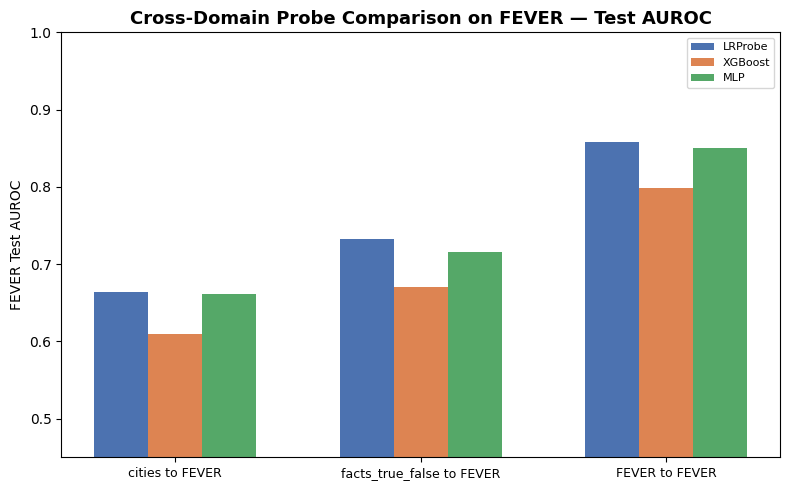

In [ ]:
# Plot
fig, ax = plt.subplots(figsize=(8, 5))

exp_labels = list(experiments.keys())
x = np.arange(len(exp_labels))
width = 0.22
colors = ['#4C72B0', '#DD8452', '#55A868']

for i, probe in enumerate(probes):
    vals = [experiments[e][probe]['test']['auroc'] for e in exp_labels]
    ax.bar(x + i * width, vals, width, label=probe, color=colors[i])

ax.set_xticks(x + width)
ax.set_xticklabels(exp_labels, fontsize=9)
ax.set_ylabel('FEVER Test AUROC')
ax.set_title('Cross-Domain Probe Comparison on FEVER — Test AUROC', fontsize=13, fontweight='bold')
ax.set_ylim(0.45, 1.0)
# ax.axhline(0.5, color='gray', ls='--', lw=0.8, label='chance')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()